In [ ]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 3.2 MB/s eta 0:00:00


In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class Product():
    def __init__(self, name, space, price):
        self.name = name
        self.space = space
        self.price = price

In [ ]:
products_list = []
products_list.append(Product('Refrigerator A', 0.751, 999.90))
products_list.append(Product('Cell phone', 0.00000899, 2199.12))
products_list.append(Product('TV 55', 0.400, 4346.99))
products_list.append(Product("TV 50' ", 0.290, 3999.90))
products_list.append(Product("TV 42' ", 0.200, 2999.00))
products_list.append(Product("Notebook A", 0.00350, 2499.90))
products_list.append(Product("Ventilator", 0.496, 199.90))
products_list.append(Product("Microwave A", 0.0424, 308.66))
products_list.append(Product("Microwave B", 0.0544, 429.90))
products_list.append(Product("Microwave C", 0.0319, 299.29))
products_list.append(Product("Refrigerator B", 0.635, 849.00))
products_list.append(Product("Refrigerator C", 0.870, 1199.89))
products_list.append(Product("Notebook B", 0.498, 1999.90))
products_list.append(Product("Notebook C", 0.527, 3999.00))

In [ ]:
for product in products_list:
    print(product.name, ' - ', product.price, ' - ', product.space)

Refrigerator A  -  999.9  -  0.751
Cell phone  -  2199.12  -  8.99e-06
TV 55  -  4346.99  -  0.4
TV 50'   -  3999.9  -  0.29
TV 42'   -  2999.0  -  0.2
Notebook A  -  2499.9  -  0.0035
Ventilator  -  199.9  -  0.496
Microwave A  -  308.66  -  0.0424
Microwave B  -  429.9  -  0.0544
Microwave C  -  299.29  -  0.0319
Refrigerator B  -  849.0  -  0.635
Refrigerator C  -  1199.89  -  0.87
Notebook B  -  1999.9  -  0.498
Notebook C  -  3999.0  -  0.527


In [ ]:
space_limit = 3 # не можна взяти товарів більше ніж на 3 м³

spaces = np.array([p.space for p in products_list])
prices = np.array([p.price for p in products_list])
names = [p.name for p in products_list]

In [ ]:
print("Кількість товарів:", len(names))
print("Об'єми:", spaces)
print("Ціни:", prices)
print("Обмеження:", space_limit)

Кількість товарів: 14
Об'єми: [7.51e-01 8.99e-06 4.00e-01 2.90e-01 2.00e-01 3.50e-03 4.96e-01 4.24e-02
 5.44e-02 3.19e-02 6.35e-01 8.70e-01 4.98e-01 5.27e-01]
Ціни: [ 999.9  2199.12 4346.99 3999.9  2999.   2499.9   199.9   308.66  429.9
  299.29  849.   1199.89 1999.9  3999.  ]
Обмеження: 3


In [ ]:
penalty_coeff = 10000

def fitness_func(ga_instance, solution, solution_idx):
    # solution 1 - беремо, 0 - не беремо
    total_space = np.sum(solution * spaces) # сумарний об’єм вибраних товарів
    total_price = np.sum(solution * prices) # сумарну вартість вибраних товарів
    # Якщо набір товарів не влізає в 3 м³, ми даємо йому дуже малий fitness
    # якщо обмеження порушено, зменшуємо fitness пропорційно перевищенню об'єму
    if total_space > space_limit:
        penalty = (total_space - space_limit) * penalty_coeff
        return total_price - penalty

    return total_price

Для підвищення якості пошуку доцільно використовувати не жорсткий, а м’який штраф за порушення обмеження, який залежить від величини перевищення допустимого об’єму. Такий підхід дає генетичному алгоритму більше інформації про якість проміжних рішень і покращує збіжність на задачах більшої розмірності.

In [ ]:
np.random.seed(42)

sol_per_pop = 8
num_genes = len(products_list)

initial_population = np.random.randint(0, 2, size=(sol_per_pop, num_genes))

print("Початкова популяція:")
print(initial_population)
print("Форма:", initial_population.shape)

Початкова популяція:
[[0 1 0 0 0 1 0 0 0 1 0 0 0 0]
 [1 0 1 1 1 0 1 0 1 1 1 1 1 1]
 [1 1 0 0 1 1 1 0 1 0 0 0 0 0]
 [1 1 1 1 1 0 1 1 0 1 0 1 0 1]
 [1 0 0 0 0 0 0 0 0 1 1 0 1 1]
 [1 1 0 1 0 1 1 1 0 1 0 1 0 1]
 [0 0 1 0 1 1 1 1 1 1 1 1 1 1]
 [1 0 0 1 1 1 1 1 1 1 1 0 1 0]]
Форма: (8, 14)


In [ ]:
# параметри генетичного алгоритму
num_generations = 100           # Скільки поколінь пройде алгоритм.
num_parents_mating = 4          # Скільки батьківських хромосом беруть участь у створенні нових рішень
parent_selection_type = "sss"   # steady-state selection.
crossover_type = "single_point" # хромосоми “розрізаються” в одній точці і обмінюються частинами.
mutation_type = "random"        # Тип мутації
mutation_percent_genes = 10     # Мутує 10% генів у хромосомі.
keep_parents = 2                # Зберігає 2 батьківські хромосоми в наступному поколінні.

ga_instance = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=fitness_func,
    initial_population=initial_population,
    gene_type=int,
    gene_space=[0, 1],
    parent_selection_type=parent_selection_type,
    crossover_type=crossover_type,
    mutation_type=mutation_type,
    mutation_percent_genes=mutation_percent_genes,
    keep_parents=keep_parents,
    random_seed=42
)

In [ ]:
# Запуск алгоритму
ga_instance.run()
# Отримання найкращого рішення
solution, solution_fitness, solution_idx = ga_instance.best_solution()

print("Найкраща хромосома: ", solution)
print("Найкращий fitness: ", solution_fitness)

# Обчислення підсумкових значень
total_space = np.sum(solution * spaces)
total_price = np.sum(solution * prices)

print(f"\nЗагальний об'єм: {total_space:.4f}")
print(f"Загальна вартість: {total_price:.2f}")

if total_space <= space_limit:
    print("Рішення допустиме.")
else:
    print("Рішення недопустиме.")

# Виведення вибраних товарів
selected_products = []

for i in range(len(solution)):
    if solution[i] == 1:
        selected_products.append(products_list[i])

print("\nВибрані товари:")
for product in selected_products:
    print(f"Назва товару: {product.name:20} Ціна: {product.price:8.2f}   Об'єм: {product.space:.6f}")

Найкраща хромосома:  [0 1 1 1 1 1 0 1 0 1 0 1 1 1]
Найкращий fitness:  23851.649999999998

Загальний об'єм: 2.8628
Загальна вартість: 23851.65
Рішення допустиме.

Вибрані товари:
Назва товару: Cell phone           Ціна:  2199.12   Об'єм: 0.000009
Назва товару: TV 55                Ціна:  4346.99   Об'єм: 0.400000
Назва товару: TV 50'               Ціна:  3999.90   Об'єм: 0.290000
Назва товару: TV 42'               Ціна:  2999.00   Об'єм: 0.200000
Назва товару: Notebook A           Ціна:  2499.90   Об'єм: 0.003500
Назва товару: Microwave A          Ціна:   308.66   Об'єм: 0.042400
Назва товару: Microwave C          Ціна:   299.29   Об'єм: 0.031900
Назва товару: Refrigerator C       Ціна:  1199.89   Об'єм: 0.870000
Назва товару: Notebook B           Ціна:  1999.90   Об'єм: 0.498000
Назва товару: Notebook C           Ціна:  3999.00   Об'єм: 0.527000


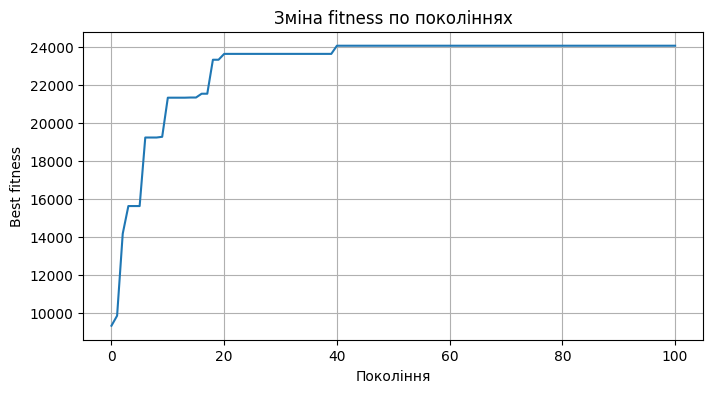

In [ ]:
import matplotlib.pyplot as plt

fitness_values = ga_instance.best_solutions_fitness

plt.figure(figsize=(8, 4))

plt.plot(fitness_values)

plt.xlabel("Покоління")
plt.ylabel("Best fitness")
plt.title("Зміна fitness по поколіннях")

plt.grid()
plt.show()

Алгоритм швидко покращує рішення на перших поколіннях і вже приблизно до 20–40 покоління досягає максимального значення fitness, після чого відбувається стабілізація. Це свідчить про швидку збіжність і ефективність генетичного алгоритму для даної задачі.

In [ ]:
import pandas as pd

crossover_list = ["single_point", "two_points", "uniform"]
mutation_list = ["random", "swap", "inversion", "scramble"]

results = []

for crossover_type in crossover_list:
    for mutation_type in mutation_list:
        ga_instance = pygad.GA(
            num_generations=100,
            num_parents_mating=4,
            fitness_func=fitness_func,
            initial_population=initial_population.copy(),
            gene_type=int,
            gene_space=[0, 1],
            parent_selection_type="sss",
            crossover_type=crossover_type,
            mutation_type=mutation_type,
            mutation_percent_genes=10,
            keep_parents=2,
            random_seed=42
        )

        ga_instance.run()

        solution, solution_fitness, solution_idx = ga_instance.best_solution(
            ga_instance.last_generation_fitness
        )

        total_space = np.sum(solution * spaces)
        total_price = np.sum(solution * prices)

        results.append({
            "crossover": crossover_type,
            "mutation": mutation_type,
            "best_fitness": solution_fitness,
            "total_price": total_price,
            "total_space": total_space
        })

results_df = pd.DataFrame(results)
print(results_df)

best_row = results_df.sort_values(by="best_fitness", ascending=False).iloc[0]
print("\nНайкраща комбінація параметрів:")
print(best_row)

       crossover   mutation  best_fitness  total_price  total_space
0   single_point     random      24281.55     24281.55     2.917209
1   single_point       swap      24081.56     24081.56     2.798209
2   single_point  inversion      24281.55     24281.55     2.917209
3   single_point   scramble      24281.55     24281.55     2.917209
4     two_points     random      24081.56     24081.56     2.798209
5     two_points       swap      19982.27     19982.27     2.972309
6     two_points  inversion      24281.55     24281.55     2.917209
7     two_points   scramble      24281.55     24281.55     2.917209
8        uniform     random      24281.55     24281.55     2.917209
9        uniform       swap      23930.66     23930.66     2.682209
10       uniform  inversion      24281.55     24281.55     2.917209
11       uniform   scramble      24081.56     24081.56     2.798209

Найкраща комбінація параметрів:
crossover       single_point
mutation              random
best_fitness        24281

У ході виконання роботи було застосовано генетичний алгоритм для розв’язання задачі рюкзака з 14 товарами за умови обмеження на загальний об’єм не більше 3 м³. Отримані результати показали, що генетичний алгоритм є ефективним інструментом для задач даного типу, оскільки дозволяє знаходити оптимальні або близькі до оптимальних рішення без необхідності повного перебору всіх можливих комбінацій.

У процесі дослідження було проаналізовано вплив різних типів кросоверу (single_point, two_points, uniform) та мутації (random, swap, inversion, scramble) на якість розв’язку. Максимальне значення функції пристосованості (24281.55) було досягнуто для більшості комбінацій параметрів, зокрема при використанні мутації типу random, inversion та scramble у поєднанні з різними типами кросоверу. Це свідчить про високу стабільність алгоритму та його здатність знаходити глобальний оптимум.

Аналіз отриманих результатів показав, що тип кросоверу не має суттєвого впливу на якість кінцевого рішення, оскільки всі розглянуті варіанти забезпечують подібні результати. Водночас тип мутації має більший вплив: мутація типу random демонструє стабільно високі результати, тоді як використання мутації типу swap у деяких випадках призводить до помітного зниження якості розв’язку.

Таким чином, генетичний алгоритм є доцільним для розв’язання задачі рюкзака, а найбільш ефективною комбінацією параметрів у даному випадку є використання мутації типу random у поєднанні з будь-яким із досліджених типів кросоверу.

Отримані результати також свідчать про те, що для задач невеликої розмірності генетичний алгоритм швидко сходиться до оптимального рішення незалежно від вибору більшості параметрів.